In [ ]:
from langgraph.graph import START, END, StateGraph, add_messages
from langgraph.types import Send
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_community.document_loaders import WikipediaLoader
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, AnyMessage, get_buffer_string
from langchain_core.runnables import RunnableConfig

from pydantic import BaseModel, Field

from IPython.display import Image, display, Markdown
from dotenv import load_dotenv

import os
from typing import List, Annotated
import operator

In [3]:
load_dotenv()
def _check_env(var: str):
    if not os.environ.get(var):
        raise ValueError(f"No env variable for {var}")

In [4]:
_check_env("OPENAI_API_KEY")
_check_env("LANGSMITH_API_KEY")
_check_env("TAVILY_API_KEY")

In [5]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

### Schemas

In [6]:
class AnalystPersona(BaseModel): #pydantic for validation
    name: str = Field(
        description="Name of the analyst."
    )
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )

    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

class AnalystPersonas(BaseModel):
    analysts: List[AnalystPersona] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )

class WholeGraphState(BaseModel):
    # nones are used below for (in)convenience
    max_analysts: int
    topic: str
    human_analyst_feedback: str | None = None
    analysts: list[AnalystPersona] = []
    sections: Annotated[list, operator.add] = []
    introduction: str | None = None
    content: str | None = None 
    conclusion: str | None = None
    final_report: str | None = None
    # document_type: Literal['article', 'research_paper']

### Analysts

In [7]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [8]:
def create_analysts(state: WholeGraphState) -> dict:
    topic = state.topic
    max_analysts = state.max_analysts
    human_analyst_feedback = state.human_analyst_feedback or ''
    
    structured_llm = llm.with_structured_output(AnalystPersonas)
    system_message = analyst_instructions.format(topic=topic, human_analyst_feedback=human_analyst_feedback, max_analysts=max_analysts)
    
    personas = structured_llm.invoke([SystemMessage(system_message)] + [HumanMessage(content="Generate the analyst personas")])
    
    return {"analysts" : personas.analysts}

def get_human_feedback(state: WholeGraphState):
    pass

def should_continue(state: WholeGraphState) -> str:
    '''Return next node after human feedback'''
    human_analyst_feedback = state.human_analyst_feedback or None
    if human_analyst_feedback:
        return 'create_analysts'
    return END

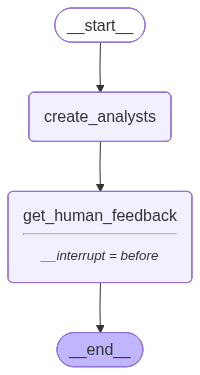

In [9]:
builder = StateGraph(WholeGraphState)

builder.add_node("create_analysts", create_analysts)
builder.add_node("get_human_feedback", get_human_feedback)

builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "get_human_feedback")
builder.add_conditional_edges("get_human_feedback", should_continue)

memory = MemorySaver()
graph = builder.compile(interrupt_before=['get_human_feedback'], checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


### Create Analysts Demonstration

In [10]:
graph_state = WholeGraphState(
    max_analysts=3,
    topic="The adoption of AI in SMEs in Africa",
    human_analyst_feedback=None,
    analysts=[]  
)
thread = RunnableConfig(configurable= {"thread_id": "1"})

for event in graph.stream(graph_state, config=thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 


Name: Dr. Amina Okafor
Affiliation: University of Lagos
Role: Technology Adoption Specialist
Description: Dr. Amina Okafor focuses on understanding the factors that influence the adoption of AI technologies in small and medium-sized enterprises (SMEs) across Africa. Her research is particularly concerned with identifying the barriers to AI adoption, such as lack of infrastructure, skills gap, and financial constraints. She aims to provide insights that can help policymakers and business leaders create supportive environments for AI integration in SMEs.
--------------------------------------------------
Name: Kwame Mensah
Affiliation: African Development Bank
Role: Economic Impact Analyst
Description: Kwame Mensah analyzes the economic implications of AI adoption in African SMEs. His work involves assessing how AI can drive productivity, innovation, and competitiveness in the SME sector. Kwame is particularly interested in the potential for AI to create new business opportunities and jo

In [11]:
current_state = graph.get_state(thread)
print(current_state.next)
current_state

('get_human_feedback',)


StateSnapshot(values={'max_analysts': 3, 'topic': 'The adoption of AI in SMEs in Africa', 'human_analyst_feedback': None, 'analysts': [AnalystPersona(name='Dr. Amina Okafor', affiliation='University of Lagos', role='Technology Adoption Specialist', description='Dr. Amina Okafor focuses on understanding the factors that influence the adoption of AI technologies in small and medium-sized enterprises (SMEs) across Africa. Her research is particularly concerned with identifying the barriers to AI adoption, such as lack of infrastructure, skills gap, and financial constraints. She aims to provide insights that can help policymakers and business leaders create supportive environments for AI integration in SMEs.'), AnalystPersona(name='Kwame Mensah', affiliation='African Development Bank', role='Economic Impact Analyst', description='Kwame Mensah analyzes the economic implications of AI adoption in African SMEs. His work involves assessing how AI can drive productivity, innovation, and compet

In [ ]:
graph.update_state(thread, 
                   {"human_analyst_feedback":"Add in someone from a startup to add an entrepreneur perspective"},
                   as_node="get_human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b80cc-73c4-6e69-8002-23af8438cc9f'}}

In [13]:
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Amina Okafor
Affiliation: University of Lagos
Role: Technology Adoption Specialist
Description: Dr. Amina Okafor focuses on understanding the factors that influence the adoption of AI technologies in small and medium-sized enterprises (SMEs) across Africa. Her research is particularly concerned with identifying the barriers to AI adoption, such as lack of infrastructure, skills gap, and financial constraints. She aims to provide insights that can help policymakers and business leaders create supportive environments for AI integration in SMEs.
--------------------------------------------------
Name: Kwame Mensah
Affiliation: African Development Bank
Role: Economic Impact Analyst
Description: Kwame Mensah analyzes the economic implications of AI adoption in African SMEs. His work involves assessing how AI can drive productivity, innovation, and competitiveness in the SME sector. Kwame is particularly interested in the potential for AI to create new business opportunities and jo

### Conduct Interview

#### Ask Question

In [58]:
class InterviewState(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]
    context: Annotated[list[str], operator.add] = []
    interview: str | None = None
    max_num_of_turns: int = 2
    analyst: AnalystPersona 
    sections: list[str] = []
    

question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""


In [59]:
def generate_question(state: InterviewState) -> dict:
    analyst = state.analyst
    messages = state.messages

    system_message = question_instructions.format(goals=analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    return {"messages" : [question]}

def route_messages(state: InterviewState, 
                   name: str = "expert"):
    ''' Route between question and answer '''
    
    messages = state.messages
    max_num_turns = state.max_num_of_turns

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question
    # If the question content contains thank you so much for your help, it skips to save the interview
    last_question = messages[-1] 
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    return [
            Send("search_web", state),
            Send("search_wikipedia", state)
        ]

#### Search Web + Wikipedia

- Using Tavily to search for relevant information to answer the question

In [60]:
class SearchQuery(BaseModel):
    search_query: str | None = Field(None, description="Search query for retrieval.")

search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

In [61]:
tavily_search = TavilySearch(max_results=3)

def search_web(state: InterviewState) -> dict:
    '''Search web using Tavily'''
    structured_llm = llm.with_structured_output(SearchQuery)
    output = structured_llm.invoke([search_instructions] +  state.messages)

    output = tavily_search.invoke({"query": output.search_query})
    search_results = output.get("results", output)
    
    formatted_search_results = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_results
        ]
    )

    return {"context": [formatted_search_results]}

def search_wikipedia(state: InterviewState) -> dict:
    '''Search Wikipidea'''
    structured_llm = llm.with_structured_output(SearchQuery)
    output = structured_llm.invoke([search_instructions]+state.messages)
    
    search_results = WikipediaLoader(query=output.search_query, load_max_docs=3).load()
    
    formatted_search_results = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_results
        ]
    )

    return {"context": [formatted_search_results]}

#### Generate Answer

In [62]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [63]:
def generate_answer(state: InterviewState):
    """ Answer a question """
    # Get state
    analyst = state.analyst
    messages = state.messages
    context = state.context

    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    return {"messages": [answer]}

def save_interview(state: InterviewState):
    ''' Save interviews '''
    
    interview = get_buffer_string(state.messages)
    
    return {"interview": interview}

#### Write Section

In [64]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [65]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    interview = state.interview
    context = state.context
    analyst = state.analyst
   
    # Write section using either the both source docs and interview
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context} {interview}")]) 
                
    return {"sections": [section.content]}

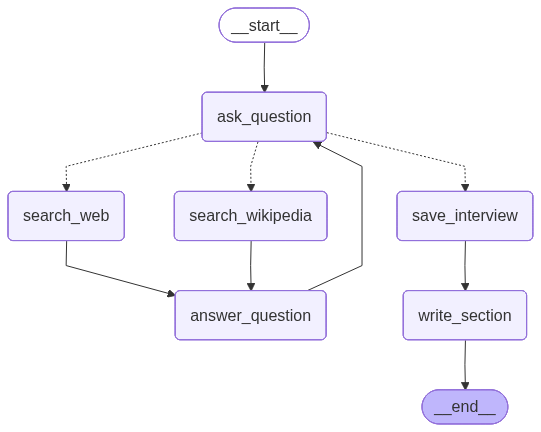

In [ ]:
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_wikipedia", search_wikipedia)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

# Flow
interview_builder.add_edge(START, "ask_question")
interview_builder.add_conditional_edges("ask_question", route_messages, path_map=["search_web", "search_wikipedia", "save_interview"])
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("answer_question", "ask_question")
interview_builder.add_edge("search_wikipedia", "answer_question")
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

display(Image(interview_graph.get_graph().draw_mermaid_png()))


#### Trial Interview

In [67]:
trial_interview = InterviewState(
    messages=[],
    context=[],
    max_num_of_turns=2,
    analyst=analysts[0],
    sections=[]
)
thread = RunnableConfig(
    configurable={
        "thread_id":1
    }
)
interview = interview_graph.invoke(trial_interview,thread)
Markdown(interview['sections'][0])

## Unlocking AI Potential: Overcoming Barriers in Kenyan SMEs

### Summary

The adoption of Artificial Intelligence (AI) in Small and Medium Enterprises (SMEs) across Africa, particularly in Kenya, presents both significant opportunities and formidable challenges. As Dr. Mwangi explores the dynamics of AI integration, several key factors emerge as critical to understanding the landscape of AI adoption in Kenyan SMEs.

Despite the transformative potential of AI to enhance competitiveness and innovation, Kenyan SMEs face several barriers that hinder its adoption. A primary challenge is the skills shortage, where businesses struggle to find personnel with the necessary technical expertise to implement and manage AI technologies effectively [1]. This skills gap is a significant impediment, as it limits the ability of SMEs to leverage AI for operational improvements and strategic decision-making.

Data security risks also pose a substantial concern for Kenyan SMEs. The potential for data breaches and the complexities of handling sensitive information deter many businesses from fully embracing AI technologies [1]. This apprehension underscores the need for robust data protection measures and regulatory frameworks to build trust and confidence in AI systems.

Financial constraints further exacerbate the challenges of AI adoption. The initial investment and ongoing costs associated with AI technologies are often prohibitive for small businesses [3]. This financial burden is compounded by the lack of technical skills, creating a cycle that stifles innovation and growth.

To address these barriers, strategic interventions are essential. Training programs aimed at building technical expertise can help bridge the skills gap, while financial support mechanisms can alleviate the cost burden, making AI technologies more accessible to SMEs. Additionally, partnerships with tech firms offering AI solutions can provide the necessary expertise and resources to facilitate AI integration [4].

Moreover, AI-driven marketing strategies have been identified as a potential enabler of digital transformation. By enhancing the link between AI adoption and firm performance, these strategies can improve competitiveness and drive business growth [6]. Such approaches, combined with efforts to address financial and skills-related challenges, can empower Kenyan SMEs to harness the full potential of AI.

In conclusion, while the path to AI adoption in Kenyan SMEs is fraught with challenges, targeted strategies and interventions can unlock significant opportunities for innovation and competitiveness. By addressing skills shortages, data security concerns, and financial constraints, SMEs can position themselves to thrive in an increasingly digital economy.

### Sources
[1] https://www.researchgate.net/publication/385376885_The_Adoption_of_Generative_AI_in_Kenya_A_Critical_Analysis_of_Opportunities_Challenges_and_Strategic_Imperatives  
[3] https://strategicjournals.com/index.php/journal/article/view/2920  
[4] https://www.lipabiz.com/unleashing-potential-how-ai-transforms-small-businesses-in-kenya  
[6] https://www.sciencedirect.com/science/article/pii/S2773067025000330  

### Parallelized Interviews

In [68]:
def initiate_all_interviews(state: WholeGraphState):
    """ Run each interview using send in parallel"""    
    if state.human_analyst_feedback or not state.analysts:
        return "create_analysts"

    else:
        topic = state.topic
        return [Send
                ("conduct_interview", 
                 InterviewState(
                     analyst=analyst,
                     messages=[HumanMessage(content=f"So you said you were writing an article on {topic}?")],
                     )) for analyst in state.analysts]


In [69]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [70]:
def write_report(state: WholeGraphState):
    # Full set of sections
    sections = state.sections 
    topic = state.topic

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

def write_introduction(state: WholeGraphState):
    # Full set of sections
    sections = state.sections
    topic = state.topic

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

def write_conclusion(state: WholeGraphState):
    # Full set of sections
    sections = state.sections
    topic = state.topic

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

def finalize_report(state: WholeGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state.content
    if content and state.introduction and state.conclusion:
        if content.startswith("## Insights"):
            content = content.strip("## Insights")
        if "## Sources" in content:
            try:
                content, sources = content.split("\n## Sources\n")
            except:
                sources = None
        else:
            sources = None

        final_report = state.introduction + "\n\n---\n\n" + content + "\n\n---\n\n" + state.conclusion
        if sources is not None:
            final_report += "\n\n## Sources\n" + sources
        return {"final_report": final_report}
    raise ValueError(f"Content, intro, or conclusion mising")

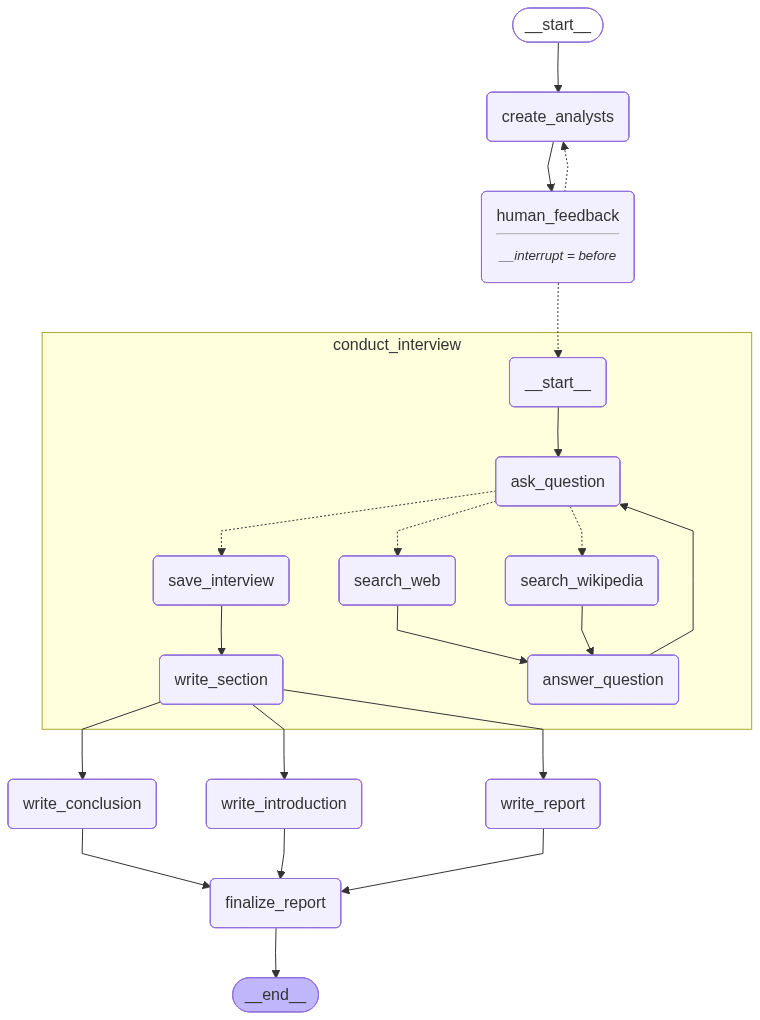

In [71]:
builder = StateGraph(WholeGraphState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", get_human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_introduction", "write_conclusion", "write_report"], "finalize_report")
builder.add_edge("finalize_report", END)

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [77]:
graph_state = WholeGraphState(
    max_analysts=3,
    topic="The adoption of AI in SMEs in Africa, with a focus on Kenya",
    human_analyst_feedback=None,
    analysts=[]  
)

thread = RunnableConfig(configurable= {"thread_id": "1"})

for event in graph.stream(graph_state, config=thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Amina Mwangi
Affiliation: University of Nairobi, Department of Computer Science
Role: AI Adoption Researcher
Description: Dr. Mwangi focuses on understanding the factors that influence the adoption of AI technologies in SMEs in Kenya. Her research aims to identify the barriers and enablers of AI integration, with a particular interest in how local cultural, economic, and infrastructural contexts affect these processes. She is motivated by the potential of AI to drive economic growth and innovation in African SMEs.
--------------------------------------------------
Name: John Kamau
Affiliation: Kenya Association of Manufacturers
Role: SME Technology Consultant
Description: John Kamau works directly with SMEs to help them integrate AI solutions into their business operations. He is concerned with practical implementation challenges, such as cost, training, and scalability of AI technologies. His goal is to provide SMEs with actionable insights and strategies to leverage AI for 

In [78]:
graph.update_state(thread, 
                   {"human_analyst_feedback":"Add in an SME owner who is keen on integrating tech in their business"},
                   as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b810c-9e0b-6813-8009-cce7606074e3'}}

In [79]:
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Amina Mwangi
Affiliation: University of Nairobi, Department of Computer Science
Role: AI Adoption Researcher
Description: Dr. Mwangi focuses on understanding the factors that influence the adoption of AI technologies in SMEs in Kenya. Her research aims to identify the barriers and enablers of AI integration, with a particular interest in how local cultural, economic, and infrastructural contexts affect these processes. She is motivated by the potential of AI to drive economic growth and innovation in African SMEs.
--------------------------------------------------
Name: John Kamau
Affiliation: Kenya Association of Manufacturers
Role: SME Technology Consultant
Description: John Kamau works directly with SMEs to help them integrate AI solutions into their business operations. He is concerned with practical implementation challenges, such as cost, training, and scalability of AI technologies. His goal is to provide SMEs with actionable insights and strategies to leverage AI for 

In [80]:
graph.update_state(thread, {"human_analyst_feedback": 
                            None}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b810c-ecf7-654e-800b-8688e6daf023'}}

In [81]:
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

--Node--
conduct_interview
--Node--
conduct_interview
--Node--
conduct_interview
--Node--
write_conclusion
--Node--
write_introduction
--Node--
write_report
--Node--
finalize_report


In [82]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# The Adoption of AI in SMEs in Africa: A Focus on Kenya

## Introduction

The integration of Artificial Intelligence (AI) into Small and Medium Enterprises (SMEs) in Africa, particularly in Kenya, is a dynamic process shaped by cultural, economic, and infrastructural factors. This report explores the cultural dichotomy in technology adoption, highlighting both resistance and openness among Kenyan entrepreneurs. It examines economic barriers such as resource constraints and the need for robust policy frameworks to support AI integration. The report also delves into practical AI applications in Kenyan SMEs, showcasing opportunities for growth and innovation. Finally, it discusses the role of government policies in empowering SMEs to harness AI's potential, driving productivity and competitiveness.

---



The adoption of Artificial Intelligence (AI) in Small and Medium Enterprises (SMEs) in Kenya is a complex process influenced by cultural, economic, and infrastructural factors. Cultural attitudes significantly impact AI adoption, with traditional business practices often creating skepticism towards AI, perceived as impersonal compared to conventional methods. However, younger entrepreneurs in Kenya are more open to innovation, viewing AI as a tool for competitive advantage, which serves as a crucial enabler for AI integration [1][2].

Economically, SMEs face barriers such as financial constraints and limited access to technological infrastructure, hindering their ability to invest in AI solutions. Institutional readiness, including policy and regulatory frameworks, has only a weak positive influence on AI adoption, indicating a need for more robust support systems [3]. Despite these challenges, increasing digital literacy and mobile technology proliferation provide a foundation for AI adoption, with businesses recognizing AI's potential to enhance efficiency and competitiveness.

AI offers immense opportunities for growth, particularly in the manufacturing sector, by automating tasks, optimizing supply chains, and improving decision-making through data analysis. Successful implementations in Kenyan businesses include AI-driven inventory management and personalized marketing strategies, which enhance customer engagement and sales. However, skills shortages and data security concerns remain significant obstacles [1][2][3].

The Kenyan government has recognized AI's potential and developed policies to foster its adoption, such as the National AI Strategy 2025-2030, which outlines a vision for AI integration across sectors. This strategy aims to promote economic growth through AI-enabled productivity and enhanced service delivery. However, SMEs still face challenges like insufficient infrastructure and limited access to funding, highlighting the need for targeted government policies to address these barriers [3].

AI adoption in Kenyan SMEs is also transforming traditional business models, creating innovative opportunities for market exploration and revenue generation. AI-powered chatbots, for instance, have revolutionized customer service, reducing wait times and improving satisfaction. However, technological readiness, leadership vision, and competitive pressure influence AI adoption, necessitating strategic approaches to overcome these challenges [2].

To address these barriers, targeted interventions such as tax breaks or grants for technology investments can help lower financial obstacles. An incremental approach to AI implementation, leveraging partnerships, and prioritizing ethical practices are crucial strategies for unlocking AI's potential. Despite these challenges, AI can drive innovation and efficiency, providing SMEs with a competitive edge in a fast-evolving economy [3].

In conclusion, while AI presents transformative opportunities for Kenyan SMEs, particularly in the manufacturing sector, the path to adoption requires addressing significant challenges. By investing in skills development, robust data security measures, and supportive policies, SMEs can harness AI's power to enhance productivity and competitiveness in the global market.


---

## Conclusion

The adoption of AI in Kenyan SMEs presents a transformative opportunity, yet it is accompanied by significant challenges. Cultural attitudes and economic constraints, such as resource readiness and policy support, play crucial roles in shaping AI integration. Despite these barriers, the potential for AI to enhance productivity and competitiveness, particularly in the manufacturing sector, is immense. Government policies, like Kenya's National AI Strategy, are pivotal in fostering an enabling environment. By addressing financial, infrastructural, and skill-related challenges, and leveraging AI's innovative capabilities, Kenyan SMEs can unlock growth and innovation, positioning themselves for success in the digital economy.

## Sources
[1] https://journalijsra.com/sites/default/files/fulltext_pdf/IJSRA-2025-0009.pdf  
[2] https://www.researchgate.net/publication/388162117_AI_adoption_and_sustainability_of_SMES_in_Africa_Opportunities_and_challenges  
[3] https://carijournals.org/journals/JTS/article/view/2797?srsltid=AfmBOopz-xYKrEiuWdoqVkOGiq2QXU-UGjHc-Ful8TvifgOhgS6gVE_e  
[4] https://ict.go.ke/sites/default/files/2025-03/Kenya%20AI%20Strategy%202025%20-%202030.pdf  
[5] https://www.nucamp.co/blog/coding-bootcamp-kenya-ken-government-how-ai-is-helping-government-companies-in-kenya-cut-costs-and-improve-efficiency  
[6] https://taxnews.ey.com/news/2025-2193-kenya-releases-the-national-ai-strategy-2025-2030  
[7] https://www.lipabiz.com/unlocking-growth-for-smes-in-kenya-harnessing-the-power-of-ai  
[8] https://www.sciencedirect.com/science/article/pii/S2773067025000330  
[9] https://www.linkedin.com/pulse/role-artificial-intelligence-growth-small-businesses-beavon-magare-pletf  
[10] https://www.researchgate.net/publication/367678657_Exploring_the_barriers_to_Artificial_Intelligence_adoption_in_sub-Saharan_Africa's_Small_and_Medium_Enterprises_and_the_potential_for_increased_productivity  
[11] https://cmr.berkeley.edu/assets/documents/pdf/2025-03-harnessing-ai-for-entrepreneurs-overcoming-barriers-to-drive-digital-growth.pdf  
[12] https://odi.co.za/ai-for-smmes-why-now-is-africas-moment-to-build-smarter-factories  
[13] https://strategicjournals.com/index.php/journal/article/view/2920  
[14] https://www.africadataprotection.org/Kenya_AI_Strategy_2025_2030.pdf